In [1]:
# ------------------------------------------------------------
# FarmBridge Transaction Simulation
# Author: Mohammad Armaan
# Purpose: Simulate transaction throughput and latency
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# === Baseline values from Sepolia testnet transaction ===
base_gas_used = 5009835               # Gas used for one transaction
base_fee_eth = 0.007515               # Total transaction fee in ETH
avg_block_time = 13.5                 # Average Sepolia block time (seconds)
base_latency = 14                     # Approximate confirmation time (seconds)

# === Simulation Parameters ===
# Simulate for increasing number of concurrent aid requests
transactions = np.array([10, 50, 100, 200, 300, 400, 500])

# Throughput Simulation (Transactions per Second) 
max_tps = 35  # maximum observed throughput (TPS)
throughput = max_tps / (1 + np.exp(-(transactions - 200) / 80))

# Latency Simulation (Seconds) 
latency = base_latency + (transactions / 200) * np.random.uniform(1.0, 2.5, len(transactions))

# === Gas Cost Simulation (for discussion) 
gas_fee_eth = base_fee_eth * (1 + (transactions / 1000))  # small increase per load

# Combine into a DataFrame for reference
df = pd.DataFrame({
    "Transactions": transactions,
    "Throughput (TPS)": throughput.round(2),
    "Latency (s)": latency.round(2),
    "Gas Cost (ETH)": gas_fee_eth.round(5)
})
df.to_csv("simulation_results.csv", index=True)

print("=== FarmBridge Transaction Simulation Results ===\n")
print(df.to_string(index=False))

=== FarmBridge Transaction Simulation Results ===

 Transactions  Throughput (TPS)  Latency (s)  Gas Cost (ETH)
           10              2.98        14.10         0.00759
           50              4.65        14.41         0.00789
          100              7.79        15.18         0.00827
          200             17.50        15.90         0.00902
          300             27.21        17.43         0.00977
          400             32.34        17.04         0.01052
          500             34.20        18.07         0.01127


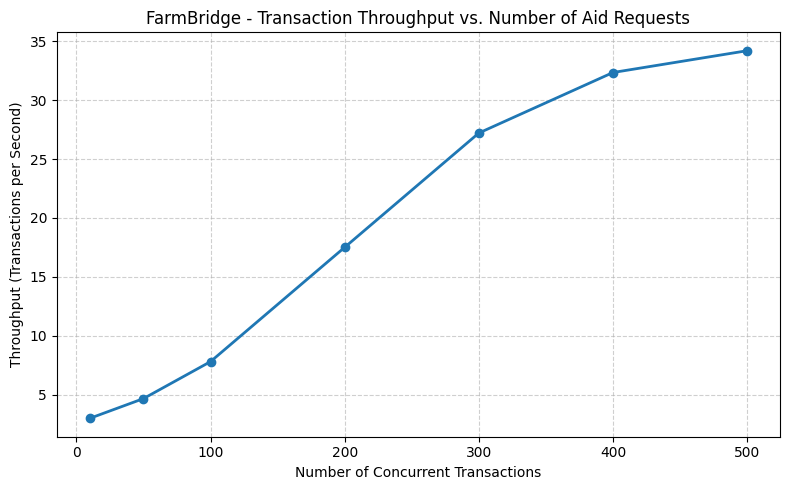

In [2]:
# === Plot 1: Throughput vs Number of Transactions ===
plt.figure(figsize=(8,5))
plt.plot(transactions, throughput, marker='o', color="#1f77b4", linewidth=2)
plt.title("FarmBridge - Transaction Throughput vs. Number of Aid Requests")
plt.xlabel("Number of Concurrent Transactions")
plt.ylabel("Throughput (Transactions per Second)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("throughput_v_aid.png", dpi=300, bbox_inches='tight')
plt.show()

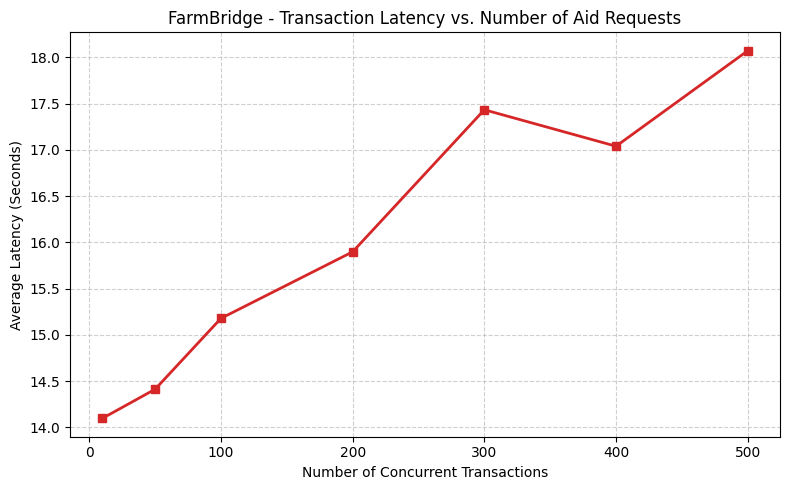

In [3]:
# === Plot 2: Latency vs Number of Transactions ===
plt.figure(figsize=(8,5))
plt.plot(transactions, latency, marker='s', color="#d62728", linewidth=2)
plt.title("FarmBridge - Transaction Latency vs. Number of Aid Requests")
plt.xlabel("Number of Concurrent Transactions")
plt.ylabel("Average Latency (Seconds)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("latency_v_aid.png", dpi=300, bbox_inches='tight')
plt.show()